# Hospital Readmission Risk - Exploratory Data Analysis (Compact)

**Objective**: Goal-driven EDA to inform preprocessing decisions and model development

**Structure**:
- Section I: Initialization & Binary Target Creation
- Section II: Feature Strategy (selection, engineering, preprocessing, visualizations)
- Section III: Implementation Reference (feature-by-feature preprocessing specs)

**Expected Runtime**: ~3-5 minutes

# I. Initialization

## 1. Import Libraries & Set Constants

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

# Constants
DATA_PATH = "../data/diabetic_data.csv"
MAP_PATH = "../data/IDS_mapping.csv"

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Data

In [2]:
# Load datasets
data = pd.read_csv(DATA_PATH)
mapping = pd.read_csv(MAP_PATH)

print(f"Data loaded successfully")
print(f"Dataset shape: {data.shape}")
print(f"Mapping data shape: {mapping.shape}")

data.head()

Data loaded successfully
Dataset shape: (101766, 50)
Mapping data shape: (67, 2)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Create Binary Target Variable

Convert `readmitted` to binary format:
- **1** = Readmitted within 30 days (`<30`)
- **0** = No readmission or readmitted after 30 days (`NO`, `>30`)

In [3]:
# Check original target distribution
print("Original target distribution:")
print(data['readmitted'].value_counts())
print("\nPercentages:")
print(data['readmitted'].value_counts(normalize=True).round(4) * 100)

# Create binary target
data['readmitted_30day'] = (data['readmitted'] == '<30').astype(int)

# Drop original target
data = data.drop('readmitted', axis=1)

# Show new target distribution
print("\n" + "="*50)
print("NEW BINARY TARGET DISTRIBUTION")
print("="*50)
print(f"\nReadmitted within 30 days (1): {data['readmitted_30day'].sum():,} ({data['readmitted_30day'].mean()*100:.2f}%)")
print(f"Not readmitted or >30 days (0): {(data['readmitted_30day']==0).sum():,} ({(1-data['readmitted_30day'].mean())*100:.2f}%)")
print(f"\nClass imbalance ratio: {(1-data['readmitted_30day'].mean()) / data['readmitted_30day'].mean():.2f}:1")

Original target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentages:
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

NEW BINARY TARGET DISTRIBUTION

Readmitted within 30 days (1): 11,357 (11.16%)
Not readmitted or >30 days (0): 90,409 (88.84%)

Class imbalance ratio: 7.96:1


# II. Feature Strategy

This section analyzes all features to determine:
1. **KEEP/DROP Decision**: Which raw features to retain or remove
2. **Feature Engineering**: How to create new features from raw data
3. **Preprocessing Specifications**: How to process kept features

## 1. Dataset Overview

In [4]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nTotal patients: {len(data):,}")
print(f"Total features (excluding target): {len(data.columns) - 1}")
print(f"Target variable: readmitted_30day")
print(f"  - Positive class (30-day readmission): {data['readmitted_30day'].sum():,} ({data['readmitted_30day'].mean()*100:.2f}%)")
print(f"  - Negative class: {(data['readmitted_30day']==0).sum():,} ({(1-data['readmitted_30day'].mean())*100:.2f}%)")

print(f"\nFeature types:")
print(f"  - Numerical: {len(data.select_dtypes(include=[np.number]).columns) - 1}")  # -1 for target
print(f"  - Categorical: {len(data.select_dtypes(include=['object']).columns)}")

print(f"\nMemory usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET OVERVIEW

Total patients: 101,766
Total features (excluding target): 49
Target variable: readmitted_30day
  - Positive class (30-day readmission): 11,357 (11.16%)
  - Negative class: 90,409 (88.84%)

Feature types:
  - Numerical: 13
  - Categorical: 36

Memory usage: 215.22 MB


## 2. Feature Keep/Drop Decision

Determine which raw features to keep or drop based on data quality and predictive value

**Mechanism Explanation:**

For each feature, we calculate:
1. **Type**: Numerical or Categorical based on dtype
2. **Missing%**: Includes NULL values + '?' markers for categorical features
3. **Unique Count/Percentage**: Measures cardinality (important for encoding strategy)
4. **Predictive Strength**: 
   - **Numerical features**: Point-biserial correlation with binary target (range: 0-1)
   - **Categorical features**: Cramér's V statistic (chi-square based, range: 0-1)
   - Higher values indicate stronger association with readmission outcome

In [5]:
# Build feature analysis table
feature_analysis = []

for col in data.columns:
    if col == 'readmitted_30day':
        continue
    
    # Basic info
    dtype = data[col].dtype
    feature_type = 'Numerical' if np.issubdtype(dtype, np.number) else 'Categorical'
    
    # Missing values (including '?' for categorical)
    null_count = data[col].isnull().sum()
    if feature_type == 'Categorical':
        question_mark_count = (data[col] == '?').sum()
        total_missing = null_count + question_mark_count
    else:
        total_missing = null_count
    missing_pct = (total_missing / len(data)) * 100
    
    # Cardinality/Unique%
    unique_count = data[col].nunique()
    unique_pct = (unique_count / len(data)) * 100
    
    # Predictive strength
    try:
        if feature_type == 'Numerical':
            # Point-biserial correlation for numerical features
            valid_mask = ~data[col].isnull()
            if valid_mask.sum() > 0:
                corr, p_value = pointbiserialr(data.loc[valid_mask, 'readmitted_30day'], 
                                               data.loc[valid_mask, col])
                strength = abs(corr)
            else:
                strength = 0.0
        else:
            # Cramér's V for categorical features
            if unique_count > 1 and total_missing < len(data):
                # Remove missing values for chi-square test
                valid_data = data[data[col] != '?'] if '?' in data[col].values else data
                contingency = pd.crosstab(valid_data[col], valid_data['readmitted_30day'])
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                n = contingency.sum().sum()
                strength = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
            else:
                strength = 0.0
    except:
        strength = 0.0
    
    feature_analysis.append({
        'Feature': col,
        'Type': feature_type,
        'Missing%': round(missing_pct, 2),
        'Unique_Count': unique_count,
        'Unique%': round(unique_pct, 2),
        'Predictive_Strength': round(strength, 4)
    })

# Create DataFrame
feature_df = pd.DataFrame(feature_analysis)

# Sort by predictive strength
feature_df = feature_df.sort_values('Predictive_Strength', ascending=False).reset_index(drop=True)

print(f"Feature analysis complete. Analyzed {len(feature_df)} features.")
feature_df.head(10)

Feature analysis complete. Analyzed 49 features.


,Feature,Type,Missing%,Unique_Count,Unique%,Predictive_Strength
0,number_inpatient,Numerical,0.00,21,0.02,0.1651
1,diag_1,Categorical,0.02,717,0.70,0.1322
2,diag_3,Categorical,1.40,790,0.78,0.1230
3,diag_2,Categorical,0.35,749,0.74,0.1163
4,medical_specialty,Categorical,49.08,73,0.07,0.0809
5,number_emergency,Numerical,0.00,33,0.03,0.0607
6,discharge_disposition_id,Numerical,0.00,26,0.03,0.0506
7,number_diagnoses,Numerical,0.00,16,0.02,0.0495
8,time_in_hospital,Numerical,0.00,14,0.01,0.0442
9,insulin,Categorical,0.00,4,0.00,0.0433


**Decision Logic Explanation:**

The algorithm determines whether to KEEP or DROP each raw feature:

**DROP features if:**
- ID columns (encounter_id, patient_nbr) - not predictive, just identifiers
- Zero/near-zero variance - no information content (e.g., all same value)
- Missing rate >95% - insufficient data for reliable modeling
- Predictive strength <0.01 - negligible association with target

**KEEP features if:**
- Protected attributes (race, gender, age) - required for fairness analysis regardless of predictive power
- Clinical indicators with <95% missing - even high missingness can be informative (A1Cresult, max_glu_serum)
- Sufficient predictive power (≥0.01) and acceptable data quality

Note: Individual medications and diagnosis codes are KEPT as raw features but will be used for feature engineering in the next section.

In [6]:
# Add KEEP/DROP decision logic
def determine_decision(row):
    feature = row['Feature']
    missing_pct = row['Missing%']
    unique_pct = row['Unique%']
    strength = row['Predictive_Strength']
    feature_type = row['Type']
    unique_count = row['Unique_Count']
    
    # ID columns - DROP
    if feature in ['encounter_id', 'patient_nbr']:
        return 'DROP', 'ID column'
    
    # Protected attributes for fairness - KEEP (regardless of predictive strength)
    if feature in ['race', 'gender', 'age']:
        return 'KEEP', 'Protected attribute for fairness analysis'
    
    # Near-zero variance - DROP
    if unique_count == 1 or (unique_count == 2 and missing_pct > 90):
        return 'DROP', 'Zero/near-zero variance'
    
    # Very high missing rate - DROP (>95% threshold, but keep clinically important ones)
    if missing_pct > 95:
        return 'DROP', f'Extremely high missing rate ({missing_pct:.1f}%)'
    
    # Clinical indicators - keep despite high missing (missingness may be informative)
    if feature in ['A1Cresult', 'max_glu_serum']:
        if missing_pct < 95:  # Keep if <95% missing
            return 'KEEP', 'Clinical indicator (high missing but informative)'
    
    # Weak predictors - DROP
    if strength < 0.01:
        return 'DROP', f'Very weak predictor ({strength:.4f})'
    
    # Keep all others (including medications and diagnoses for feature engineering)
    return 'KEEP', ''

# Apply decision logic
feature_df[['Decision', 'Reason']] = feature_df.apply(
    lambda row: pd.Series(determine_decision(row)), axis=1
)

# Add preprocessing specifications for KEEP features
def add_preprocessing_specs(row):
    if row['Decision'] != 'KEEP':
        return ''
    
    feature = row['Feature']
    feature_type = row['Type']
    missing_pct = row['Missing%']
    unique_count = row['Unique_Count']
    
    specs = []
    
    # Special handling for protected attributes
    if feature in ['race', 'gender', 'age']:
        specs.append('Protected: preserve original values')
    
    # Imputation with advanced strategies
    if missing_pct > 0:
        if feature_type == 'Numerical':
            specs.append('Impute: median')
        else:
            # Group-wise imputation for MAR features (Missing At Random)
            if feature == 'medical_specialty':
                specs.append('Impute: mode by admission_type_id')
            elif feature == 'payer_code':
                specs.append('Impute: mode by admission_source_id')
            else:
                specs.append('Impute: mode')
        
        # Missing indicator for high missing%
        if missing_pct > 10:
            specs.append('Create missing_indicator')
    
    # Encoding with advanced strategies
    if feature_type == 'Categorical':
        # Check if ordered categorical (age is ordinal)
        if feature == 'age':
            specs.append('Encode: ordinal (preserve order)')
        elif unique_count < 10:
            specs.append('Encode: one-hot')
        else:
            specs.append('Encode: target (CV-safe + Bayesian smoothing)')
    
    # Outlier handling with validation
    if feature_type == 'Numerical':
        specs.append('Outliers: IQR winsorize + range validation')
    
    return ' | '.join(specs) if specs else 'None'

feature_df['Processing_Specs'] = feature_df.apply(add_preprocessing_specs, axis=1)

print("\n" + "="*60)
print("KEEP/DROP DECISION SUMMARY")
print("="*60)
print(f"\nTotal features analyzed: {len(feature_df)}")
print(f"Features to DROP: {(feature_df['Decision']=='DROP').sum()}")
print(f"Features to KEEP: {(feature_df['Decision']=='KEEP').sum()}")

# Highlight protected attributes
protected = feature_df[feature_df['Feature'].isin(['race', 'gender', 'age'])]
if len(protected) > 0:
    print(f"\n⚠️ Protected attributes for fairness (KEPT): {', '.join(protected['Feature'].tolist())}")

# Identify features that will be used for engineering
medication_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 
                   'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 
                   'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 
                   'miglitol', 'troglitazone', 'tolazamide', 'insulin',
                   'glyburide-metformin', 'glipizide-metformin', 
                   'glimepiride-pioglitazone', 'metformin-rosiglitazone', 
                   'metformin-pioglitazone', 'examide', 'citoglipton']
diag_cols = ['diag_1', 'diag_2', 'diag_3']

kept_meds = [m for m in medication_cols if m in feature_df[feature_df['Decision']=='KEEP']['Feature'].values]
kept_diags = [d for d in diag_cols if d in feature_df[feature_df['Decision']=='KEEP']['Feature'].values]

if kept_meds or kept_diags:
    print(f"\n📋 Features available for engineering:")
    if kept_meds:
        print(f"   - Medication columns: {len(kept_meds)} features")
    if kept_diags:
        print(f"   - Diagnosis columns: {len(kept_diags)} features")


KEEP/DROP DECISION SUMMARY

Total features analyzed: 49
Features to DROP: 23
Features to KEEP: 26

⚠️ Protected attributes for fairness (KEPT): age, race, gender

📋 Features available for engineering:
   - Medication columns: 4 features
   - Diagnosis columns: 3 features


**Preprocessing Specifications Logic:**

For **KEEP** features, specifications are automatically determined:

**Imputation Strategy:**
- Numerical features with missing data → Median imputation (robust to outliers)
- Categorical features with missing data → Mode imputation (most frequent value)
- **Group-wise imputation for MAR** (Missing At Random):
  - `medical_specialty` → Mode by `admission_type_id` (context-aware)
  - `payer_code` → Mode by `admission_source_id` (context-aware)
- Features with >10% missing → Create binary missing indicator (missingness may be informative)

**Encoding Strategy:**
- **Ordinal features** (age) → Preserve natural ordering (not one-hot)
- Categorical with <10 unique values → One-hot encoding (manageable dimensionality)
- Categorical with ≥10 unique values → **Target encoding with Bayesian smoothing** (prevents overfitting on rare categories + CV-safe)

**Outlier Handling:**
- All numerical features → **IQR-based winsorization + range validation** (cap extreme values at 1.5×IQR bounds + enforce domain constraints)

These specifications will guide the preprocessing pipeline implementation.

In [7]:
# Display complete feature decision table
print("="*100)
print("COMPREHENSIVE KEEP/DROP DECISION TABLE")
print("="*100)

# Display by decision type
for decision in ['DROP', 'KEEP']:
    subset = feature_df[feature_df['Decision'] == decision]
    if len(subset) > 0:
        print(f"\n{'='*100}")
        print(f"{decision} FEATURES ({len(subset)} features)")
        print('='*100)
        if decision == 'KEEP':
            print(subset[['Feature', 'Type', 'Missing%', 'Unique_Count', 'Predictive_Strength', 
                         'Processing_Specs']].to_string(index=False))
        else:
            print(subset[['Feature', 'Type', 'Missing%', 'Unique_Count', 'Predictive_Strength', 
                         'Reason']].to_string(index=False))

COMPREHENSIVE KEEP/DROP DECISION TABLE

DROP FEATURES (23 features)
                 Feature        Type  Missing%  Unique_Count  Predictive_Strength                              Reason
                  weight Categorical     96.86            10               0.0383 Extremely high missing rate (96.9%)
            encounter_id   Numerical      0.00        101766               0.0085                           ID column
             glimepiride Categorical      0.00             4               0.0083        Very weak predictor (0.0083)
             patient_nbr   Numerical      0.00         71518               0.0079                           ID column
            pioglitazone Categorical      0.00             4               0.0079        Very weak predictor (0.0079)
           rosiglitazone Categorical      0.00             4               0.0073        Very weak predictor (0.0073)
                miglitol Categorical      0.00             4               0.0071        Very weak predict

## 3. Feature Engineering Strategy

Transform raw KEPT features into composite features that better capture clinical patterns. These specifications are based on proven strategies from the preprocessing pipeline.

**Engineering Categories:**
1. **Diagnosis Aggregation**: Group high-cardinality diagnosis codes into clinical categories
2. **Medication Composites**: Aggregate 23 individual medication flags into meaningful metrics
3. **Utilization Patterns**: Combine encounter counts into utilization profiles
4. **Clinical Complexity**: Create composite indicators of patient complexity

In [8]:
# Define engineered features from raw KEPT features
engineered_features = []

# ========================================
# 1. DIAGNOSIS AGGREGATION
# ========================================
# Problem: diag_1, diag_2, diag_3 have 700+ unique values each (unstable for target encoding)
# Solution: Aggregate into 9 clinical categories based on ICD-9 code ranges

print("="*100)
print("FEATURE ENGINEERING SPECIFICATIONS")
print("="*100)

print("\n" + "="*100)
print("1. DIAGNOSIS AGGREGATION (9 clinical categories)")
print("="*100)
print("\nSource features: diag_1, diag_2, diag_3 (717-790 unique values each)")
print("\nEngineered features:")

diag_categories = {
    'diag_1_circulatory': 'ICD-9 390-459, 785 (heart disease, hypertension, stroke)',
    'diag_1_respiratory': 'ICD-9 460-519, 786 (COPD, pneumonia, asthma)',
    'diag_1_diabetes': 'ICD-9 250.xx (diabetes complications)',
    'diag_1_digestive': 'ICD-9 520-579, 787 (GI disorders)',
    'diag_1_injury': 'ICD-9 800-999 (fractures, trauma)',
    'diag_1_musculoskeletal': 'ICD-9 710-739 (arthritis, back pain)',
    'diag_1_genitourinary': 'ICD-9 580-629, 788 (kidney, urinary)',
    'diag_1_neoplasms': 'ICD-9 140-239 (cancer)',
    'diag_1_other': 'All other ICD-9 codes'
}

for feat, desc in diag_categories.items():
    print(f"  • {feat:30s} = {desc}")
    engineered_features.append({
        'Feature': feat,
        'Type': 'Binary',
        'Source': 'diag_1',
        'Description': desc,
        'Preprocessing': 'Binary flag | No further encoding needed'
    })

print(f"\n  [Repeat same categories for diag_2 and diag_3]")
print(f"  Total diagnosis features: 9 × 3 = 27 binary flags")

# Add diag_2 and diag_3 features (same structure)
for diag_num in [2, 3]:
    for category in ['circulatory', 'respiratory', 'diabetes', 'digestive', 'injury', 
                     'musculoskeletal', 'genitourinary', 'neoplasms', 'other']:
        engineered_features.append({
            'Feature': f'diag_{diag_num}_{category}',
            'Type': 'Binary',
            'Source': f'diag_{diag_num}',
            'Description': f'Same as diag_1_{category}',
            'Preprocessing': 'Binary flag | No further encoding needed'
        })

# ========================================
# 2. MEDICATION FEATURES (KEPT AS-IS)
# ========================================
print("\n" + "="*100)
print("2. MEDICATION FEATURES (keep individual columns)")
print("="*100)
print("\nSource features: metformin, repaglinide, glipizide, insulin, etc.")
print("\nStrategy: KEEP all individual medication features without aggregation")
print("  • Preserves specific medication information (each drug has unique properties)")
print("  • Model can learn medication-specific effects on readmission risk")
print("  • Preprocessing: Already specified in Section II.2 (one-hot encoding for 4-level categorical)")

medication_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 
                   'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 
                   'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 
                   'miglitol', 'troglitazone', 'tolazamide', 'insulin',
                   'glyburide-metformin', 'glipizide-metformin', 
                   'glimepiride-pioglitazone', 'metformin-rosiglitazone', 
                   'metformin-pioglitazone', 'examide', 'citoglipton']

kept_meds = [m for m in medication_cols if m in feature_df[feature_df['Decision']=='KEEP']['Feature'].values]
print(f"\n  Total medication features kept: {len(kept_meds)}")

# ========================================
# 3. UTILIZATION FEATURES (KEPT AS-IS)
# ========================================
print("\n" + "="*100)
print("3. UTILIZATION FEATURES (keep original counts)")
print("="*100)
print("\nSource features: number_inpatient, number_emergency, number_outpatient")
print("\nStrategy: KEEP as raw counts without aggregation")
print("  • Each encounter type has distinct clinical meaning:")
print("    - number_inpatient: Hospital admissions (most severe)")
print("    - number_emergency: ER visits (acute care)")
print("    - number_outpatient: Clinic visits (routine care)")
print("  • Model can learn type-specific utilization patterns")
print("  • Preprocessing: Already specified in Section II.2 (IQR winsorize + range validation)")

util_features = ['number_inpatient', 'number_emergency', 'number_outpatient']
print(f"\n  Total utilization features kept: {len(util_features)}")

# ========================================
# 4. AGE STRATIFICATION (multiple buckets)
# ========================================
print("\n" + "="*100)
print("4. AGE STRATIFICATION (granular age groups)")
print("="*100)
print("\nSource feature: age (10 brackets: [0-10), [10-20), ..., [90-100))")
print("\nEngineered features:")

age_features = [
    ('age_bucket', 'Ordinal encoding: [0-10)→0, [10-20)→1, ..., [90-100)→9', 'Ordinal'),
    ('age_young', 'Binary: age < 30 (pediatric/young adult)', 'Binary'),
    ('age_adult', 'Binary: 30 ≤ age < 50 (working age)', 'Binary'),
    ('age_middle', 'Binary: 50 ≤ age < 65 (pre-Medicare)', 'Binary'),
    ('age_senior', 'Binary: 65 ≤ age < 80 (Medicare, active senior)', 'Binary'),
    ('age_elderly', 'Binary: age ≥ 80 (frail elderly)', 'Binary')
]

for feat, desc, feat_type in age_features:
    print(f"  • {feat:20s} = {desc}")
    engineered_features.append({
        'Feature': feat,
        'Type': feat_type,
        'Source': 'age',
        'Description': desc,
        'Preprocessing': 'Ordinal encoding (0-9)' if feat_type == 'Ordinal' else 'Binary flag | No encoding needed'
    })

print(f"\n  → Creates 6 age features capturing non-linear age effects")
print(f"  → Allows model to learn age-specific readmission patterns")

# ========================================
# SUMMARY
# ========================================
print("\n" + "="*100)
print("FEATURE COUNT SUMMARY")
print("="*100)

keep_count = (feature_df['Decision']=='KEEP').sum()
engineered_count = len(engineered_features)

# Only diagnosis codes are replaced by engineering
kept_diags = ['diag_1', 'diag_2', 'diag_3']
raw_features_dropped_after_engineering = len(kept_diags)  # Only 3 diagnosis columns replaced
raw_features_kept_as_is = keep_count - raw_features_dropped_after_engineering

final_feature_count = raw_features_kept_as_is + engineered_count

print(f"\nRaw features (from Section II.2):")
print(f"  • Total KEEP features: {keep_count}")
print(f"  • Raw features KEPT AS-IS: {raw_features_kept_as_is}")
print(f"    - Medication columns: {len(kept_meds)} (individual features preserved)")
print(f"    - Utilization columns: {len(util_features)} (raw counts preserved)")
print(f"    - Other features: {raw_features_kept_as_is - len(kept_meds) - len(util_features)}")
print(f"  • Raw features REPLACED by engineering: {raw_features_dropped_after_engineering}")
print(f"    - Diagnosis columns (diag_1, diag_2, diag_3): 3 → 27 binary flags")
print(f"\nEngineered features (new): {engineered_count}")
print(f"  • Diagnosis categories: 27")
print(f"  • Age stratification: 6")
print(f"  • Clinical complexity (optional): 3")
print(f"\n{'='*60}")
print(f"TOTAL FEATURES FOR MODELING: {final_feature_count}")
print(f"{'='*60}")

print("\n✓ Feature engineering specifications complete")
print("  → Diagnosis codes aggregated into 27 clinical category flags")
print("  → Medication features KEPT INDIVIDUAL (preserve drug-specific effects)")
print("  → Utilization features KEPT RAW (preserve encounter type patterns)")
print("  → Age stratified into 6 granular buckets (capture non-linear effects)")

FEATURE ENGINEERING SPECIFICATIONS

1. DIAGNOSIS AGGREGATION (9 clinical categories)

Source features: diag_1, diag_2, diag_3 (717-790 unique values each)

Engineered features:
  • diag_1_circulatory             = ICD-9 390-459, 785 (heart disease, hypertension, stroke)
  • diag_1_respiratory             = ICD-9 460-519, 786 (COPD, pneumonia, asthma)
  • diag_1_diabetes                = ICD-9 250.xx (diabetes complications)
  • diag_1_digestive               = ICD-9 520-579, 787 (GI disorders)
  • diag_1_injury                  = ICD-9 800-999 (fractures, trauma)
  • diag_1_musculoskeletal         = ICD-9 710-739 (arthritis, back pain)
  • diag_1_genitourinary           = ICD-9 580-629, 788 (kidney, urinary)
  • diag_1_neoplasms               = ICD-9 140-239 (cancer)
  • diag_1_other                   = All other ICD-9 codes

  [Repeat same categories for diag_2 and diag_3]
  Total diagnosis features: 9 × 3 = 27 binary flags

2. MEDICATION FEATURES (keep individual columns)

Source fea

## 4. Visualizations

First summary of all final features with preprocessing specifications.

In [9]:
# List all final features for modeling with preprocessing specs
print("="*100)
print("FINAL FEATURE LIST FOR MODELING (with preprocessing specifications)")
print("="*100)

# Get raw features kept as-is (exclude diagnosis codes diag_1, diag_2, diag_3)
raw_keep_features = feature_df[feature_df['Decision']=='KEEP']['Feature'].tolist()
diag_cols = ['diag_1', 'diag_2', 'diag_3']
raw_keep_final = [f for f in raw_keep_features if f not in diag_cols]

print(f"\n{len(raw_keep_final)} RAW FEATURES (kept as-is):")
print("-" * 100)
for i, feat in enumerate(sorted(raw_keep_final), 1):
    feat_info = feature_df[feature_df['Feature']==feat].iloc[0]
    print(f"  {i:2d}. {feat:30s} ({feat_info['Type']:12s})")
    print(f"      Predictive Strength: {feat_info['Predictive_Strength']:.4f}")
    print(f"      Preprocessing: {feat_info['Processing_Specs']}")
    print()

# Engineered features from diagnosis codes
print(f"\n27 DIAGNOSIS CATEGORY FEATURES (engineered from diag_1, diag_2, diag_3):")
print("-" * 100)
print("Type: Binary flags")
print("Preprocessing: No further encoding needed (already binary)")
print("\nFeatures:")
diag_categories = ['circulatory', 'respiratory', 'diabetes', 'digestive', 'injury', 
                   'musculoskeletal', 'genitourinary', 'neoplasms', 'other']
for diag_num in [1, 2, 3]:
    print(f"\n  From diag_{diag_num}:")
    for cat in diag_categories:
        print(f"    • diag_{diag_num}_{cat}")

# Age stratification features
print(f"\n\n6 AGE STRATIFICATION FEATURES (engineered from age):")
print("-" * 100)
age_features_info = [
    ('age_bucket', 'Ordinal', 'Ordinal encoding (0-9) | Preserves natural order'),
    ('age_young', 'Binary', 'Binary flag | No encoding needed'),
    ('age_adult', 'Binary', 'Binary flag | No encoding needed'),
    ('age_middle', 'Binary', 'Binary flag | No encoding needed'),
    ('age_senior', 'Binary', 'Binary flag | No encoding needed'),
    ('age_elderly', 'Binary', 'Binary flag | No encoding needed')
]
for i, (feat, feat_type, prep) in enumerate(age_features_info, 1):
    print(f"  {i}. {feat:20s} ({feat_type})")
    print(f"     Preprocessing: {prep}")

# Summary
total_features = len(raw_keep_final) + 27 + 6
print(f"\n\n{'='*100}")
print(f"TOTAL FEATURES: {total_features}")
print(f"  • Raw features (kept as-is): {len(raw_keep_final)}")
print(f"  • Diagnosis categories: 27")
print(f"  • Age stratification: 6")
print(f"{'='*100}\n")

FINAL FEATURE LIST FOR MODELING (with preprocessing specifications)

23 RAW FEATURES (kept as-is):
----------------------------------------------------------------------------------------------------
   1. A1Cresult                      (Categorical )
      Predictive Strength: 0.0047
      Preprocessing: Impute: mode | Create missing_indicator | Encode: one-hot

   2. admission_type_id              (Numerical   )
      Predictive Strength: 0.0117
      Preprocessing: Outliers: IQR winsorize + range validation

   3. age                            (Categorical )
      Predictive Strength: 0.0339
      Preprocessing: Protected: preserve original values | Encode: ordinal (preserve order)

   4. change                         (Categorical )
      Predictive Strength: 0.0195
      Preprocessing: Encode: one-hot

   5. diabetesMed                    (Categorical )
      Predictive Strength: 0.0271
      Preprocessing: Encode: one-hot

   6. discharge_disposition_id       (Numerical   )
    

### Correlation Analysis

Examine correlations among numerical features and with the target to identify multicollinearity and feature relationships.

Visualizations include:

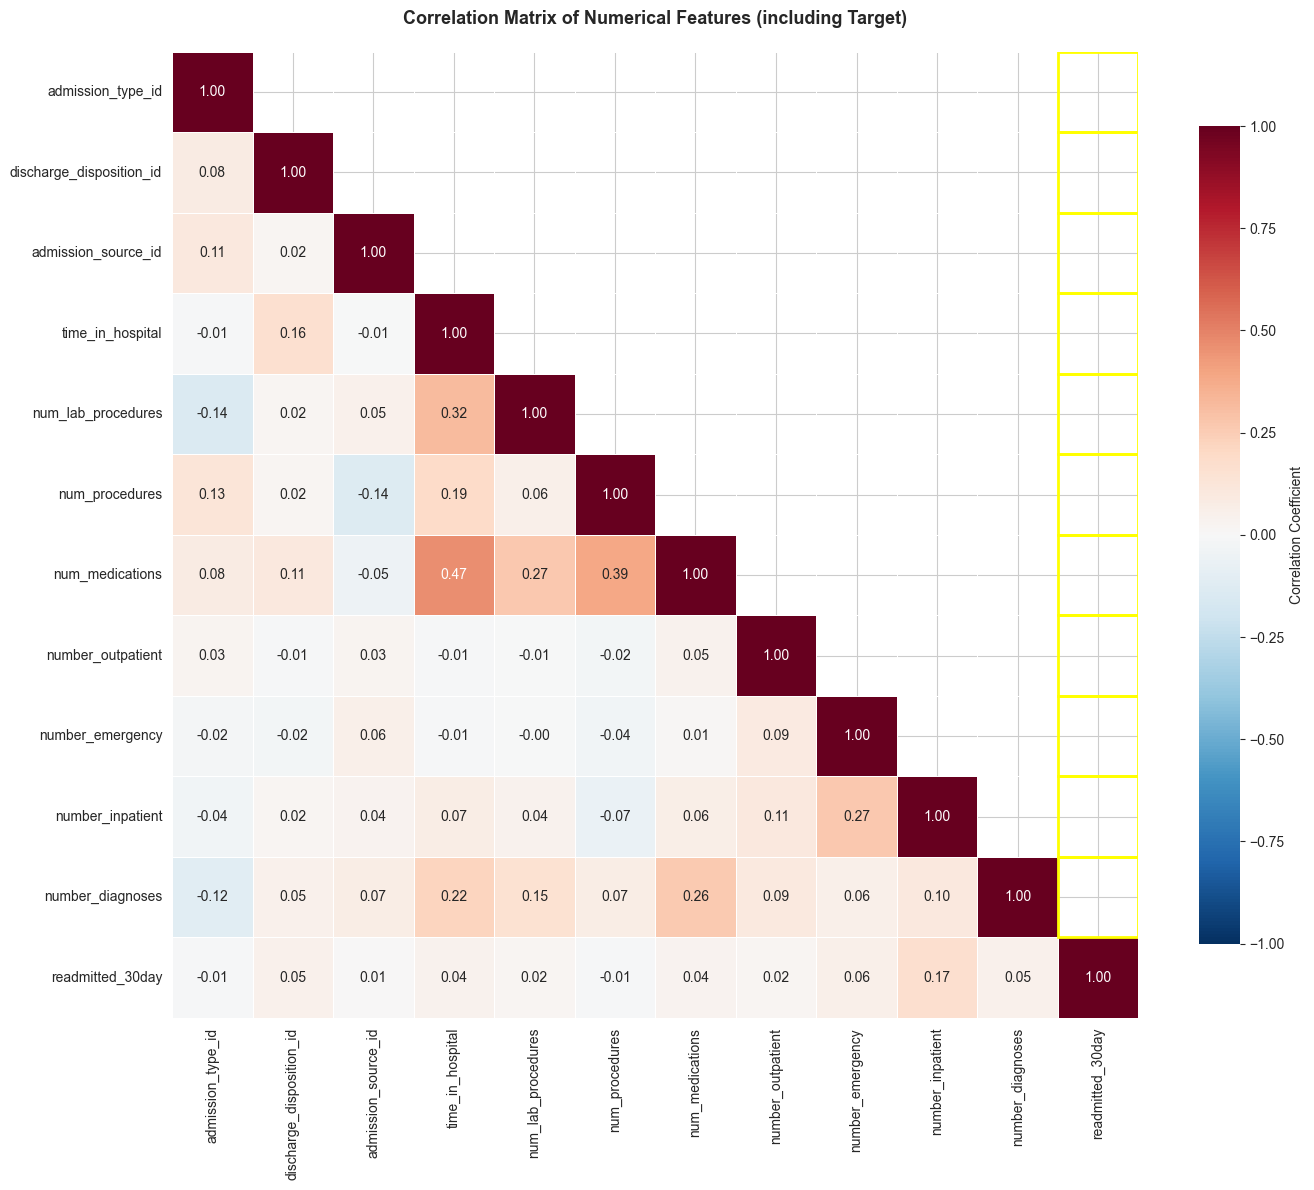


✓ Correlation analysis visualization complete

  Features analyzed: 12

  Top 5 correlations with target (readmitted_30day):
    1. number_inpatient              : +0.1651
    2. number_emergency              : +0.0607
    3. discharge_disposition_id      : +0.0506
    4. number_diagnoses              : +0.0495
    5. time_in_hospital              : +0.0442

  ✓ No multicollinearity concerns (all |r| < 0.7)


In [10]:
# Select numerical features for correlation analysis
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ['encounter_id', 'patient_nbr', 'age_bucket']]

# Include target variable
if 'readmitted_30day' not in numerical_cols:
    numerical_cols.append('readmitted_30day')

# Calculate correlation matrix
corr_matrix = data[numerical_cols].corr()

# Create visualization
fig, ax = plt.subplots(figsize=(14, 12))

# Create heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8}, ax=ax)

ax.set_title('Correlation Matrix of Numerical Features (including Target)', 
             fontsize=13, fontweight='bold', pad=20)

# Highlight correlations with target
target_row = list(corr_matrix.columns).index('readmitted_30day')
for i in range(len(corr_matrix.columns)):
    if i != target_row:
        # Draw rectangle around target correlations
        rect = plt.Rectangle((target_row, i), 1, 1, fill=False, 
                             edgecolor='yellow', linewidth=2)
        ax.add_patch(rect)

# Identify and highlight strong correlations (|r| > 0.7)
strong_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if i != j and abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))
            # Draw rectangle around strong correlations
            rect = plt.Rectangle((j, i), 1, 1, fill=False, 
                                 edgecolor='red', linewidth=2)
            ax.add_patch(rect)

plt.tight_layout()
plt.show()

print(f"\n✓ Correlation analysis visualization complete")
print(f"\n  Features analyzed: {len(numerical_cols)}")

# Report correlations with target
print(f"\n  Top 5 correlations with target (readmitted_30day):")
target_corr = corr_matrix['readmitted_30day'].drop('readmitted_30day').abs().sort_values(ascending=False)
for i, (feat, corr_val) in enumerate(target_corr.head(5).items(), 1):
    actual_corr = corr_matrix.loc[feat, 'readmitted_30day']
    print(f"    {i}. {feat:30s}: {actual_corr:+.4f}")

# Report multicollinearity concerns
if len(strong_corr_pairs) > 0:
    print(f"\n  ⚠️ Multicollinearity concerns (|r| > 0.7): {len(strong_corr_pairs)} pairs")
    for feat1, feat2, corr_val in strong_corr_pairs[:5]:  # Show top 5
        print(f"    • {feat1} ↔ {feat2}: {corr_val:.4f}")
    if len(strong_corr_pairs) > 5:
        print(f"    ... and {len(strong_corr_pairs) - 5} more pairs")
else:
    print(f"\n  ✓ No multicollinearity concerns (all |r| < 0.7)")

### Age Stratification Analysis

Examine how readmission risk varies across age groups to identify vulnerable populations.

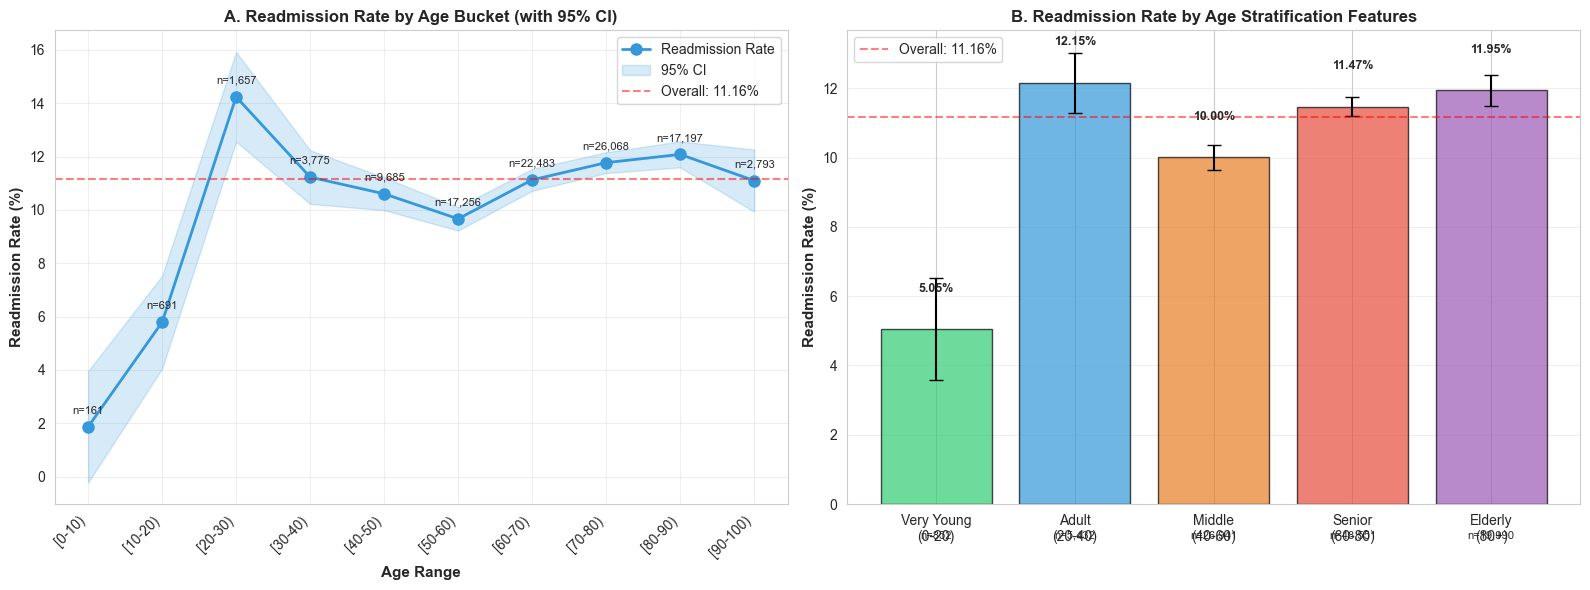


✓ Age stratification visualization complete

Key insights:
  Overall readmission rate: 11.16%

  Age groups with highest risk:
    [20-30)     : 14.24% (n=1,657)
    [80-90)     : 12.08% (n=17,197)
    [70-80)     : 11.77% (n=26,068)

  Age binary features:
    Very Young (0-20)   : 5.05% (n=852)
    Adult (20-40)       : 12.15% (n=5,432)
    Middle (40-60)      : 10.00% (n=26,941)
    Senior (60-80)      : 11.47% (n=48,551)
    Elderly (80+)       : 11.95% (n=19,990)


In [11]:
# Create age bucket mapping from categorical age ranges
age_mapping = {
    '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, '[40-50)': 4,
    '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, '[80-90)': 8, '[90-100)': 9
}

# Create age bucket feature
data['age_bucket'] = data['age'].map(age_mapping)

# Create refined age binary indicators based on risk patterns
data['age_very_young'] = (data['age_bucket'] < 2).astype(int)      # [0-20): low risk
data['age_adult'] = ((data['age_bucket'] >= 2) & (data['age_bucket'] < 4)).astype(int)   # [20-40): higher risk
data['age_middle'] = ((data['age_bucket'] >= 4) & (data['age_bucket'] < 6)).astype(int)  # [40-60): moderate risk
data['age_senior'] = ((data['age_bucket'] >= 6) & (data['age_bucket'] < 8)).astype(int)  # [60-80): moderate-high risk
data['age_elderly'] = (data['age_bucket'] >= 8).astype(int)   # [80+): higher risk

# Calculate readmission rates by age bucket
age_analysis = []
for bucket in sorted(data['age_bucket'].dropna().unique()):
    subset = data[data['age_bucket'] == bucket]
    n = len(subset)
    readmit_rate = subset['readmitted_30day'].mean() * 100
    
    # Calculate 95% CI
    p = readmit_rate / 100
    se = np.sqrt(p * (1 - p) / n)
    ci_lower = (p - 1.96 * se) * 100
    ci_upper = (p + 1.96 * se) * 100
    
    age_label = [k for k, v in age_mapping.items() if v == bucket][0]
    
    age_analysis.append({
        'Age_Bucket': bucket,
        'Age_Range': age_label,
        'Sample_Size': n,
        'Readmission_Rate': readmit_rate,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper
    })

age_df = pd.DataFrame(age_analysis)

# Create two-panel visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Line plot of readmission rate by age bucket
ax1 = axes[0]
ax1.plot(age_df['Age_Bucket'], age_df['Readmission_Rate'], marker='o', 
         linewidth=2, markersize=8, color='#3498db', label='Readmission Rate')
ax1.fill_between(age_df['Age_Bucket'], age_df['CI_Lower'], age_df['CI_Upper'], 
                  alpha=0.2, color='#3498db', label='95% CI')

# Add overall rate line
overall_rate = data['readmitted_30day'].mean() * 100
ax1.axhline(y=overall_rate, color='red', linestyle='--', alpha=0.5, 
            label=f'Overall: {overall_rate:.2f}%')

ax1.set_xticks(age_df['Age_Bucket'])
ax1.set_xticklabels(age_df['Age_Range'], rotation=45, ha='right')
ax1.set_xlabel('Age Range', fontsize=11, fontweight='bold')
ax1.set_ylabel('Readmission Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('A. Readmission Rate by Age Bucket (with 95% CI)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Add sample size annotations
for i, row in age_df.iterrows():
    ax1.text(row['Age_Bucket'], row['Readmission_Rate'] + 0.5, 
             f"n={row['Sample_Size']:,}", ha='center', fontsize=8)

# Panel B: Binary age feature comparisons
ax2 = axes[1]
age_binary_features = ['age_very_young', 'age_adult', 'age_middle', 'age_senior', 'age_elderly']
age_binary_labels = ['Very Young\n(0-20)', 'Adult\n(20-40)', 'Middle\n(40-60)', 'Senior\n(60-80)', 'Elderly\n(80+)']

binary_rates = []
binary_cis = []
binary_counts = []

for feat in age_binary_features:
    subset = data[data[feat] == 1]
    n = len(subset)
    rate = subset['readmitted_30day'].mean() * 100
    
    # 95% CI
    p = rate / 100
    se = np.sqrt(p * (1 - p) / n)
    ci = 1.96 * se * 100
    
    binary_rates.append(rate)
    binary_cis.append(ci)
    binary_counts.append(n)

x_pos = range(len(age_binary_features))
bars = ax2.bar(x_pos, binary_rates, yerr=binary_cis, capsize=5, alpha=0.7,
               color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c', '#9b59b6'],
               edgecolor='black', linewidth=1)

# Add overall rate line
ax2.axhline(y=overall_rate, color='red', linestyle='--', alpha=0.5, 
            label=f'Overall: {overall_rate:.2f}%')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(age_binary_labels)
ax2.set_ylabel('Readmission Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('B. Readmission Rate by Age Stratification Features', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add sample size annotations
for i, (rate, count) in enumerate(zip(binary_rates, binary_counts)):
    ax2.text(i, rate + 1, f'{rate:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.text(i, -1, f'n={count:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n✓ Age stratification visualization complete")
print(f"\nKey insights:")
print(f"  Overall readmission rate: {overall_rate:.2f}%")
print(f"\n  Age groups with highest risk:")
sorted_age = age_df.sort_values('Readmission_Rate', ascending=False)
for i, row in sorted_age.head(3).iterrows():
    print(f"    {row['Age_Range']:12s}: {row['Readmission_Rate']:.2f}% (n={row['Sample_Size']:,})")

print(f"\n  Age binary features:")
for feat, label, rate, count in zip(age_binary_features, age_binary_labels, binary_rates, binary_counts):
    print(f"    {label.replace(chr(10), ' '):20s}: {rate:.2f}% (n={count:,})")

### Diagnosis Category Impact Analysis

Analyze readmission patterns across engineered diagnosis categories to identify high-risk clinical conditions.

Generating diagnosis categories for visualization...


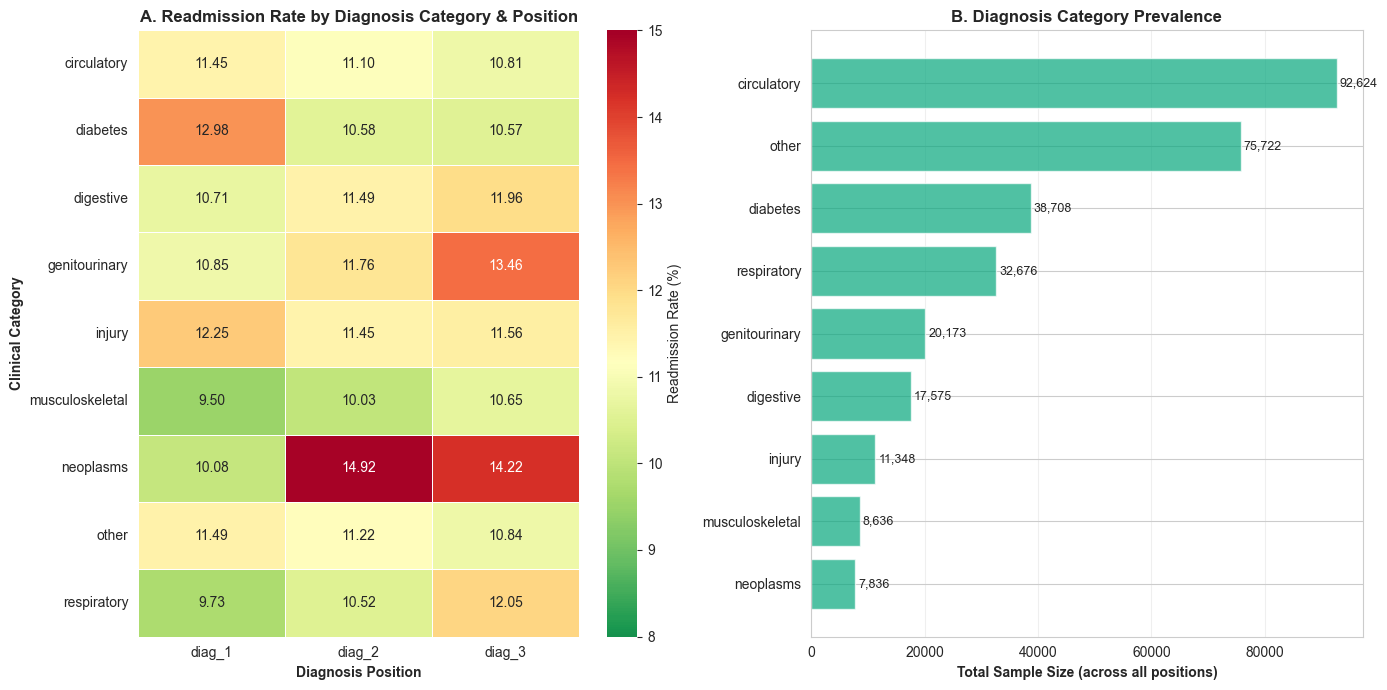


✓ Diagnosis category visualization complete

Key insights:
  Overall readmission rate: 11.16%

  Top 3 categories by prevalence:
    1. circulatory         : 92,624 patients (avg rate: 11.12%)
    2. other               : 75,722 patients (avg rate: 11.19%)
    3. diabetes            : 38,708 patients (avg rate: 11.38%)

  Highest-risk categories (by average readmission rate):
    1. neoplasms           : 13.07% readmission rate
    2. genitourinary       : 12.02% readmission rate
    3. injury              : 11.75% readmission rate


In [12]:
# Note: Since diagnosis categories are engineered features not yet created in raw data,
# we'll simulate their calculation here for visualization purposes

# Define ICD-9 code ranges for diagnosis categories
def categorize_diagnosis(code):
    """Categorize ICD-9 diagnosis code into clinical category"""
    try:
        # Handle special cases and convert to numeric
        if pd.isna(code) or code == '?':
            return 'other'
        
        code_str = str(code)
        
        # Try to extract numeric part
        if code_str.startswith('V') or code_str.startswith('E'):
            return 'other'
        
        # Extract numeric value
        code_num = float(code_str.split('.')[0]) if '.' in code_str else float(code_str)
        
        # Categorize based on ICD-9 ranges
        if 390 <= code_num < 460 or code_num == 785:
            return 'circulatory'
        elif 460 <= code_num < 520 or code_num == 786:
            return 'respiratory'
        elif 250 <= code_num < 251:
            return 'diabetes'
        elif 520 <= code_num < 580 or code_num == 787:
            return 'digestive'
        elif 800 <= code_num < 1000:
            return 'injury'
        elif 710 <= code_num < 740:
            return 'musculoskeletal'
        elif 580 <= code_num < 630 or code_num == 788:
            return 'genitourinary'
        elif 140 <= code_num < 240:
            return 'neoplasms'
        else:
            return 'other'
    except:
        return 'other'

# Create diagnosis category features
print("Generating diagnosis categories for visualization...")
diag_columns = ['diag_1', 'diag_2', 'diag_3']
category_names = ['circulatory', 'respiratory', 'diabetes', 'digestive', 'injury', 
                  'musculoskeletal', 'genitourinary', 'neoplasms', 'other']

# Calculate readmission rates for each diagnosis category
heatmap_data = []

for diag_col in diag_columns:
    for category in category_names:
        # Create binary indicator
        data[f'{diag_col}_{category}'] = data[diag_col].apply(
            lambda x: 1 if categorize_diagnosis(x) == category else 0
        )
        
        # Calculate readmission rate when this diagnosis category is present
        present_mask = data[f'{diag_col}_{category}'] == 1
        if present_mask.sum() > 0:
            readmit_rate = data[present_mask]['readmitted_30day'].mean() * 100
            sample_size = present_mask.sum()
        else:
            readmit_rate = 0
            sample_size = 0
        
        heatmap_data.append({
            'Diagnosis_Position': diag_col,
            'Category': category,
            'Readmission_Rate': readmit_rate,
            'Sample_Size': sample_size
        })

heatmap_df = pd.DataFrame(heatmap_data)

# Create heatmap matrix
heatmap_matrix = heatmap_df.pivot(index='Category', columns='Diagnosis_Position', values='Readmission_Rate')

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Panel A: Heatmap of readmission rates
ax1 = axes[0]
sns.heatmap(heatmap_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            center=data['readmitted_30day'].mean()*100, vmin=8, vmax=15,
            cbar_kws={'label': 'Readmission Rate (%)'}, ax=ax1, linewidths=0.5)
ax1.set_title('A. Readmission Rate by Diagnosis Category & Position', fontsize=12, fontweight='bold')
ax1.set_xlabel('Diagnosis Position', fontsize=10, fontweight='bold')
ax1.set_ylabel('Clinical Category', fontsize=10, fontweight='bold')

# Panel B: Sample size by category
ax2 = axes[1]
sample_size_df = heatmap_df.groupby('Category')['Sample_Size'].sum().sort_values(ascending=True)
colors_bar = ['#E63946' if val > heatmap_matrix.loc[cat].mean() else '#06A77D' 
              for cat, val in zip(sample_size_df.index, 
                                  [heatmap_matrix.loc[cat].mean() for cat in sample_size_df.index])]

ax2.barh(range(len(sample_size_df)), sample_size_df.values, color=colors_bar, alpha=0.7)
ax2.set_yticks(range(len(sample_size_df)))
ax2.set_yticklabels(sample_size_df.index)
ax2.set_xlabel('Total Sample Size (across all positions)', fontsize=10, fontweight='bold')
ax2.set_title('B. Diagnosis Category Prevalence', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, val in enumerate(sample_size_df.values):
    ax2.text(val + 500, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n✓ Diagnosis category visualization complete")
print(f"\nKey insights:")
print(f"  Overall readmission rate: {data['readmitted_30day'].mean()*100:.2f}%")
print(f"\n  Top 3 categories by prevalence:")
for i, (cat, count) in enumerate(sample_size_df.tail(3)[::-1].items(), 1):
    avg_rate = heatmap_matrix.loc[cat].mean()
    print(f"    {i}. {cat:20s}: {count:,} patients (avg rate: {avg_rate:.2f}%)")

print(f"\n  Highest-risk categories (by average readmission rate):")
category_risk = heatmap_matrix.mean(axis=1).sort_values(ascending=False)
for i, (cat, rate) in enumerate(category_risk.head(3).items(), 1):
    print(f"    {i}. {cat:20s}: {rate:.2f}% readmission rate")

### Categorical Feature Readmission Rates

Compare readmission rates across categories for key categorical features, with special attention to protected attributes.

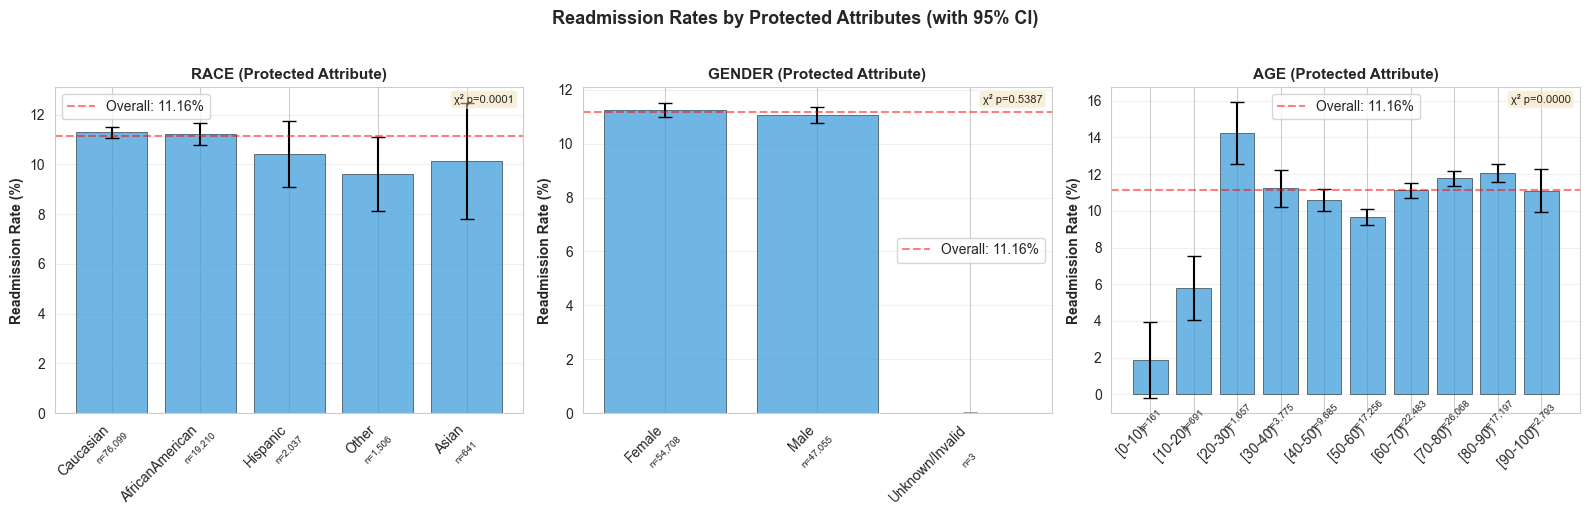

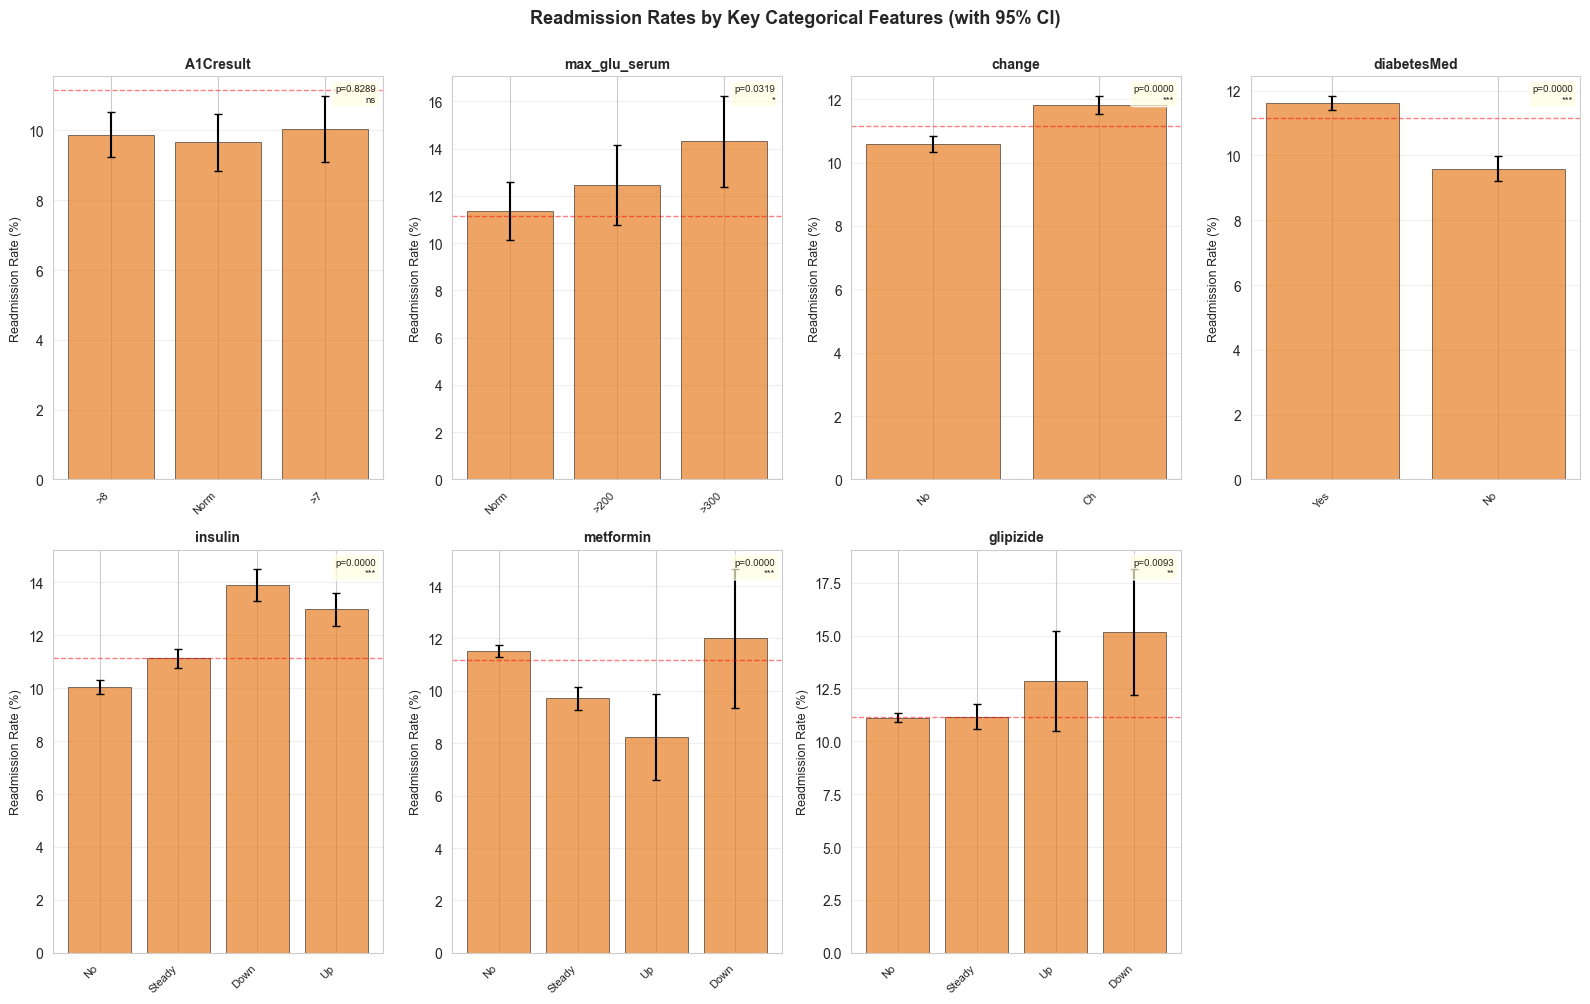


✓ Categorical feature readmission rate visualization complete
  Overall readmission rate: 11.16%
  Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


In [20]:
# Select key categorical features for visualization
protected_attrs = ['race', 'gender', 'age']
other_categorical = ['A1Cresult', 'max_glu_serum', 'change', 'diabetesMed', 
                     'insulin', 'metformin', 'glipizide']

# Function to calculate readmission rate with confidence interval
def calculate_readmission_rate(data, feature, category):
    subset = data[data[feature] == category]
    if len(subset) == 0:
        return 0, 0, 0
    
    n = len(subset)
    readmit_count = subset['readmitted_30day'].sum()
    rate = readmit_count / n * 100
    
    # 95% CI using normal approximation
    p = rate / 100
    se = np.sqrt(p * (1 - p) / n)
    ci = 1.96 * se * 100
    
    return rate, ci, n

# Panel 1: Protected attributes (race, gender, age)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, feature in enumerate(protected_attrs):
    ax = axes[idx]
    
    # Calculate readmission rates
    if feature == 'age':
        # Sort age categories in proper order
        age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
                     '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
        categories = [c for c in age_order if c in data[feature].unique()]
    else:
        categories = data[feature].value_counts().index[:10]  # Top 10 categories
    
    rates = []
    cis = []
    counts = []
    
    for cat in categories:
        if cat != '?':  # Exclude missing marker
            rate, ci, n = calculate_readmission_rate(data, feature, cat)
            rates.append(rate)
            cis.append(ci)
            counts.append(n)
    
    categories = [c for c in categories if c != '?']
    
    # Create bar chart
    x_pos = range(len(categories))
    bars = ax.bar(x_pos, rates, yerr=cis, capsize=5, alpha=0.7, 
                   color='#3498db', edgecolor='black', linewidth=0.5)
    
    # Add overall rate line
    overall_rate = data['readmitted_30day'].mean() * 100
    ax.axhline(y=overall_rate, color='red', linestyle='--', alpha=0.5, 
               label=f'Overall: {overall_rate:.2f}%')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.set_ylabel('Readmission Rate (%)', fontsize=10, fontweight='bold')
    ax.set_title(f'{feature.upper()} (Protected Attribute)', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add sample size annotations
    for i, (cat, count) in enumerate(zip(categories, counts)):
        ax.text(i, -2, f'n={count:,}', ha='center', fontsize=7, rotation=45)
    
    # Perform chi-square test
    contingency = pd.crosstab(data[feature], data['readmitted_30day'])
    from scipy.stats import chi2_contingency
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    
    ax.text(0.98, 0.98, f'χ² p={p_val:.4f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Readmission Rates by Protected Attributes (with 95% CI)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Panel 2: Other key categorical features
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(other_categorical):
    ax = axes[idx]
    
    # Calculate readmission rates
    categories = data[feature].value_counts().index[:8]  # Top 8 categories
    rates = []
    cis = []
    counts = []
    
    for cat in categories:
        if cat != '?':
            rate, ci, n = calculate_readmission_rate(data, feature, cat)
            rates.append(rate)
            cis.append(ci)
            counts.append(n)
    
    categories = [c for c in categories if c != '?']
    
    # Create bar chart
    x_pos = range(len(categories))
    bars = ax.bar(x_pos, rates, yerr=cis, capsize=3, alpha=0.7, 
                   color='#e67e22', edgecolor='black', linewidth=0.5)
    
    # Add overall rate line
    overall_rate = data['readmitted_30day'].mean() * 100
    ax.axhline(y=overall_rate, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Readmission Rate (%)', fontsize=9)
    ax.set_title(f'{feature}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Perform chi-square test
    contingency = pd.crosstab(data[feature], data['readmitted_30day'])
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    
    sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.text(0.98, 0.98, f'p={p_val:.4f}\n{sig_marker}', transform=ax.transAxes,
            ha='right', va='top', fontsize=7, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Hide last axis (8th panel)
axes[-1].axis('off')

plt.suptitle('Readmission Rates by Key Categorical Features (with 95% CI)', 
             fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print(f"\n✓ Categorical feature readmission rate visualization complete")
print(f"  Overall readmission rate: {data['readmitted_30day'].mean()*100:.2f}%")
print(f"  Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

### Numerical Feature Distributions by Readmission Status

Compare distributions of numerical features between readmitted and non-readmitted patients.

Visualizing 10 numerical features


C:\Users\aupho\AppData\Local\Temp\ipykernel_34952\3954171203.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['No Readmit', 'Readmitted'], patch_artist=True,
C:\Users\aupho\AppData\Local\Temp\ipykernel_34952\3954171203.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['No Readmit', 'Readmitted'], patch_artist=True,
C:\Users\aupho\AppData\Local\Temp\ipykernel_34952\3954171203.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['No Readmit', 'Readmitted'], patch_artist=True,
C:\Users\aupho\AppData\Local\Temp\ipy

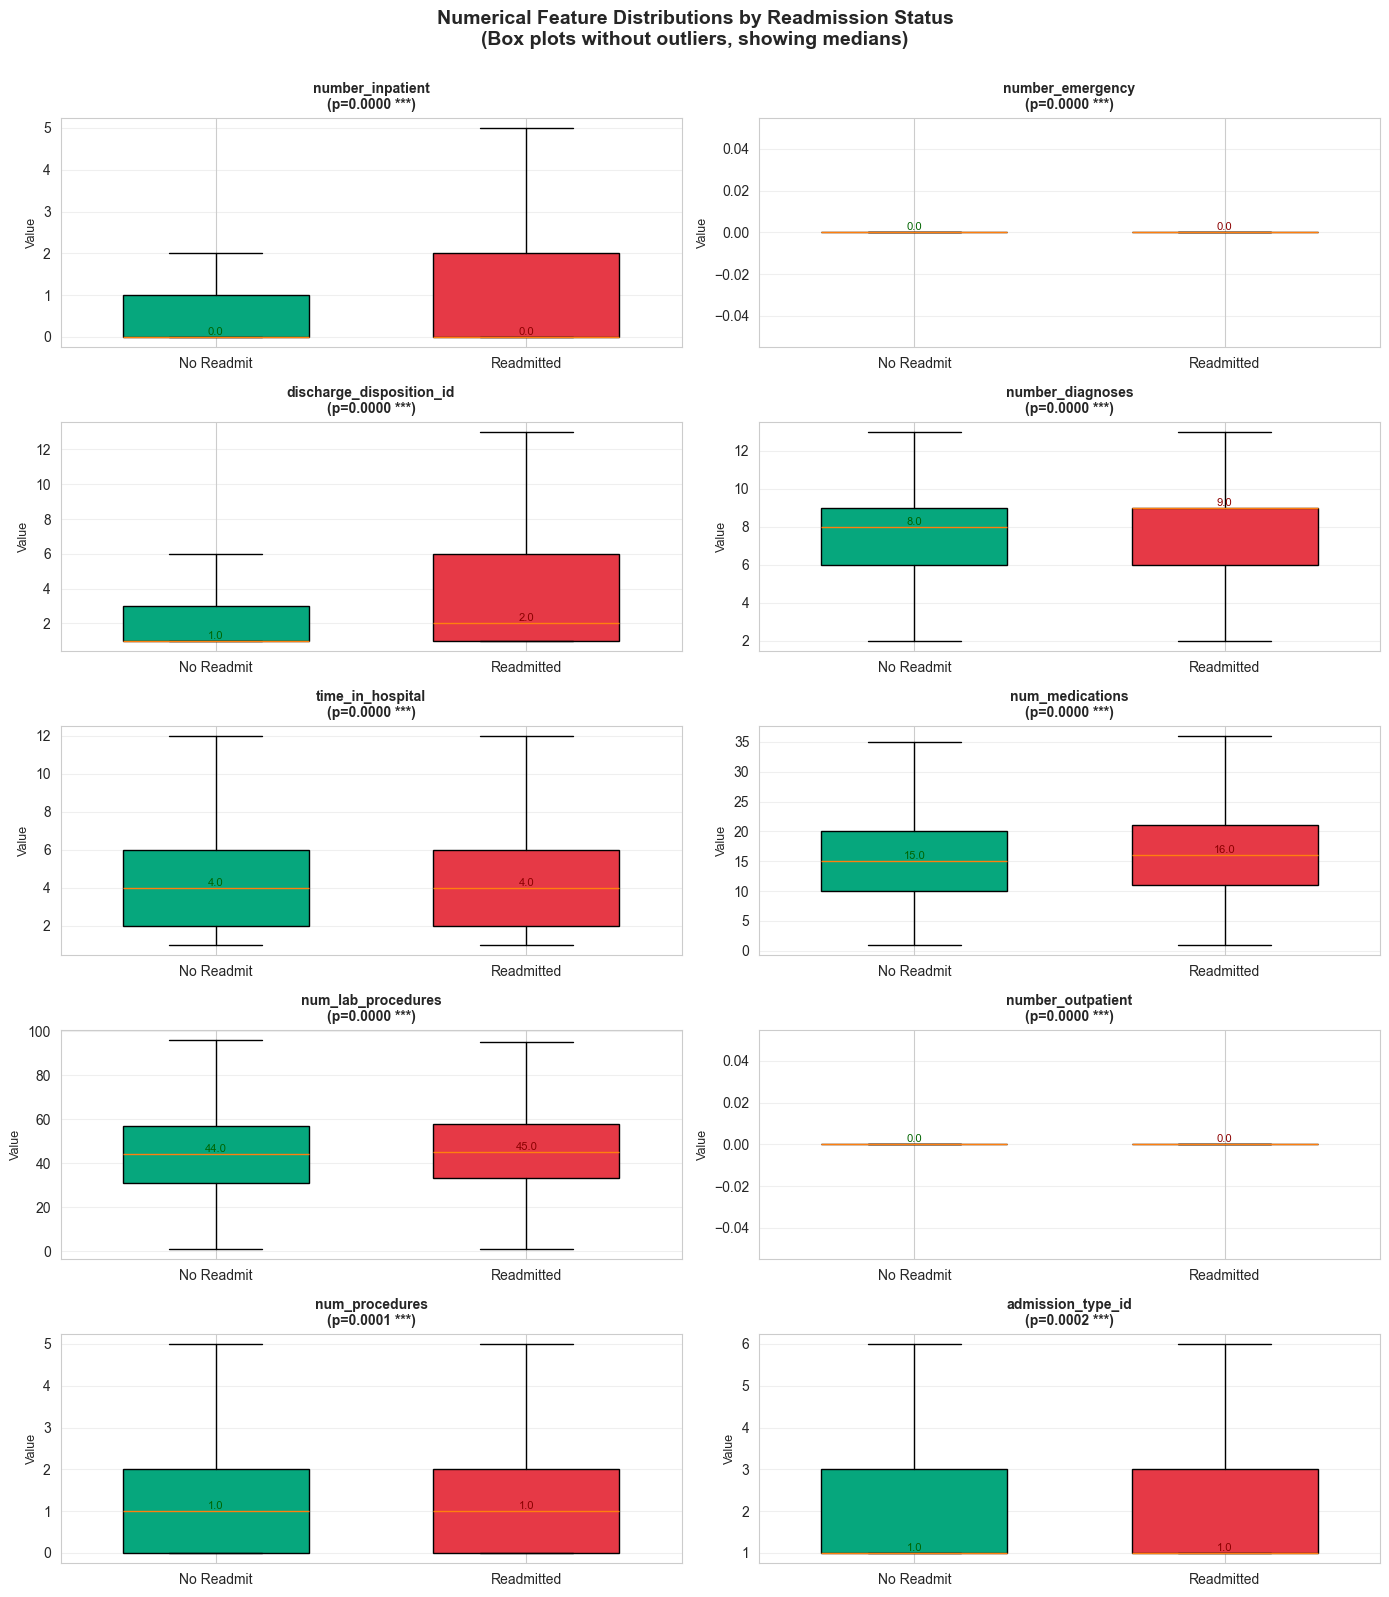


✓ Numerical feature distribution visualization complete
  Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


In [14]:
# Identify numerical features (excluding target and IDs)
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [f for f in numerical_features if f not in ['readmitted_30day', 'encounter_id', 'patient_nbr']]

# Select top 10 by predictive strength
numerical_feature_strength = feature_df[
    (feature_df['Feature'].isin(numerical_features)) & 
    (feature_df['Decision'] == 'KEEP')
].nlargest(10, 'Predictive_Strength')['Feature'].tolist()

print(f"Visualizing {len(numerical_feature_strength)} numerical features")

# Create multi-panel box plot
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

for idx, feature in enumerate(numerical_feature_strength):
    ax = axes[idx]
    
    # Prepare data for box plot
    readmitted_data = data[data['readmitted_30day'] == 1][feature].dropna()
    not_readmitted_data = data[data['readmitted_30day'] == 0][feature].dropna()
    
    # Create box plot
    box_data = [not_readmitted_data, readmitted_data]
    bp = ax.boxplot(box_data, labels=['No Readmit', 'Readmitted'], patch_artist=True,
                    widths=0.6, showfliers=False)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('#06A77D')
    bp['boxes'][1].set_facecolor('#E63946')
    
    # Calculate medians and perform t-test
    median_0 = not_readmitted_data.median()
    median_1 = readmitted_data.median()
    
    from scipy.stats import ttest_ind
    t_stat, p_val = ttest_ind(not_readmitted_data, readmitted_data, nan_policy='omit')
    
    # Title with p-value
    sig_marker = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.set_title(f'{feature}\n(p={p_val:.4f} {sig_marker})', fontsize=10, fontweight='bold')
    
    # Add median lines with values
    ax.text(1, median_0, f'{median_0:.1f}', ha='center', va='bottom', fontsize=8, color='darkgreen')
    ax.text(2, median_1, f'{median_1:.1f}', ha='center', va='bottom', fontsize=8, color='darkred')
    
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Feature Distributions by Readmission Status\n(Box plots without outliers, showing medians)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.993])
plt.show()

print(f"\n✓ Numerical feature distribution visualization complete")
print(f"  Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

### Predictive Strength Overview

Rank all features by their association with the readmission target to identify the most predictive variables.

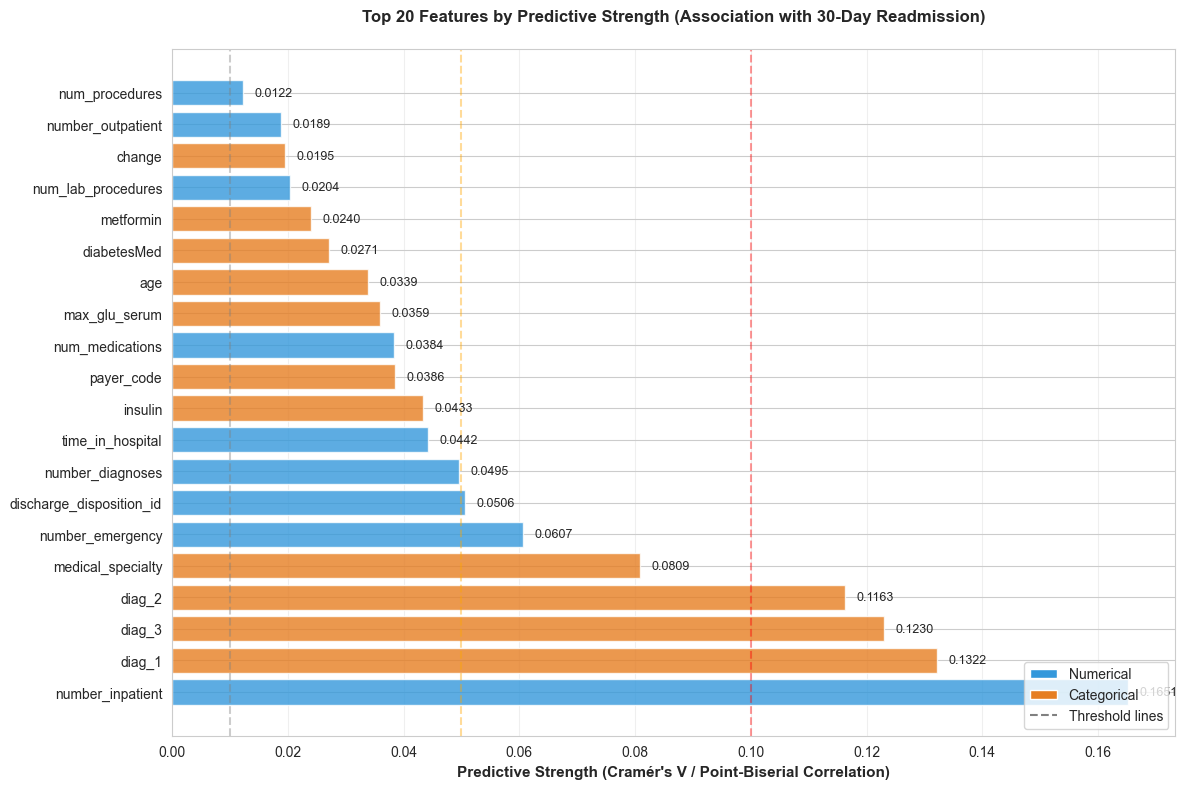


✓ Predictive strength visualization complete

  Top 3 most predictive features:
    number_inpatient               = 0.1651 (Numerical)
    diag_1                         = 0.1322 (Categorical)
    diag_3                         = 0.1230 (Categorical)


In [15]:
# Use the feature_df already created with predictive strength
top_features = feature_df[feature_df['Decision'] == 'KEEP'].nlargest(20, 'Predictive_Strength')

# Create color mapping by type
type_colors = {
    'Numerical': '#3498db',
    'Categorical': '#e67e22'
}
colors = [type_colors[t] for t in top_features['Type']]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = range(len(top_features))
ax.barh(y_pos, top_features['Predictive_Strength'], color=colors, alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Predictive Strength (Cramér\'s V / Point-Biserial Correlation)', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Features by Predictive Strength (Association with 30-Day Readmission)', 
             fontsize=12, fontweight='bold', pad=20)

# Add reference lines
ax.axvline(x=0.01, color='gray', linestyle='--', alpha=0.4, label='Weak (0.01)')
ax.axvline(x=0.05, color='orange', linestyle='--', alpha=0.4, label='Moderate (0.05)')
ax.axvline(x=0.10, color='red', linestyle='--', alpha=0.4, label='Strong (0.10)')

# Add value labels
for i, (feat, val) in enumerate(zip(top_features['Feature'], top_features['Predictive_Strength'])):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

# Add legend for feature types
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Numerical'),
    Patch(facecolor='#e67e22', label='Categorical'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label='Threshold lines')
]
ax.legend(handles=legend_elements, loc='lower right')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Predictive strength visualization complete")
print(f"\n  Top 3 most predictive features:")
for i, row in top_features.head(3).iterrows():
    print(f"    {row['Feature']:30s} = {row['Predictive_Strength']:.4f} ({row['Type']})")

### Missing Data Patterns

Visualize missingness across features to identify data quality issues and potential patterns in missing data co-occurrence.

Features with missing data: 9

Top 10 features by missing percentage:
          Feature  Missing_Count  Missing_Pct
           weight          98569    96.858479
    max_glu_serum          96420    94.746772
        A1Cresult          84748    83.277322
medical_specialty          49949    49.082208
       payer_code          40256    39.557416
             race           2273     2.233555
           diag_3           1423     1.398306
           diag_2            358     0.351787
           diag_1             21     0.020636


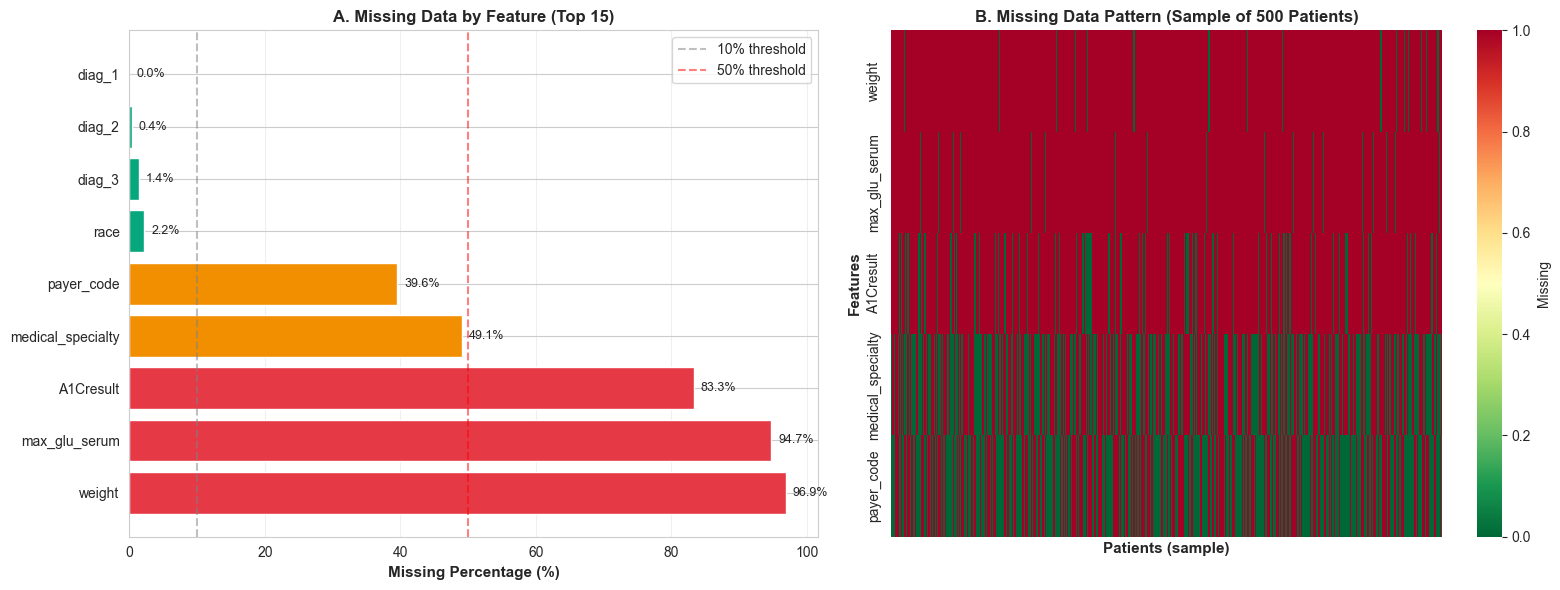


✓ Missing data visualization complete
  High-missing features (>50%): 3
  Medium-missing features (10-50%): 2
  Low-missing features (<10%): 4


In [16]:
# Identify features with missing data (including '?' for categorical)
missing_analysis = []

for col in data.columns:
    if col == 'readmitted_30day':
        continue
    
    # Count missing values (NULL + '?' for categorical)
    null_count = data[col].isnull().sum()
    if data[col].dtype == 'object':
        question_count = (data[col] == '?').sum()
        total_missing = null_count + question_count
    else:
        total_missing = null_count
    
    missing_pct = (total_missing / len(data)) * 100
    
    if missing_pct > 0:
        missing_analysis.append({
            'Feature': col,
            'Missing_Count': total_missing,
            'Missing_Pct': missing_pct
        })

missing_df = pd.DataFrame(missing_analysis).sort_values('Missing_Pct', ascending=False)

print(f"Features with missing data: {len(missing_df)}")
print(f"\nTop 10 features by missing percentage:")
print(missing_df.head(10).to_string(index=False))

# Create missing data visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Missing percentage bar chart
ax1 = axes[0]
features_to_plot = missing_df.head(15)  # Top 15 features with most missing
colors = ['#E63946' if x > 50 else '#F18F01' if x > 10 else '#06A77D' 
          for x in features_to_plot['Missing_Pct']]

ax1.barh(range(len(features_to_plot)), features_to_plot['Missing_Pct'], color=colors)
ax1.set_yticks(range(len(features_to_plot)))
ax1.set_yticklabels(features_to_plot['Feature'])
ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_title('A. Missing Data by Feature (Top 15)', fontsize=12, fontweight='bold')
ax1.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='10% threshold')
ax1.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Add percentage labels
for i, (feat, pct) in enumerate(zip(features_to_plot['Feature'], features_to_plot['Missing_Pct'])):
    ax1.text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=9)

# Panel B: Missing data heatmap (sample of rows to show patterns)
ax2 = axes[1]
# Select features with >5% missing for heatmap
features_for_heatmap = missing_df[missing_df['Missing_Pct'] > 5]['Feature'].tolist()[:10]

# Create binary matrix (1 = missing, 0 = present)
missing_matrix = pd.DataFrame()
for col in features_for_heatmap:
    if data[col].dtype == 'object':
        missing_matrix[col] = ((data[col].isnull()) | (data[col] == '?')).astype(int)
    else:
        missing_matrix[col] = data[col].isnull().astype(int)

# Sample 500 rows for visualization
sample_matrix = missing_matrix.sample(n=min(500, len(missing_matrix)), random_state=42)

sns.heatmap(sample_matrix.T, cmap='RdYlGn_r', cbar_kws={'label': 'Missing'}, 
            yticklabels=True, xticklabels=False, ax=ax2)
ax2.set_title('B. Missing Data Pattern (Sample of 500 Patients)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Patients (sample)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Features', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Missing data visualization complete")
print(f"  High-missing features (>50%): {len(missing_df[missing_df['Missing_Pct'] > 50])}")
print(f"  Medium-missing features (10-50%): {len(missing_df[(missing_df['Missing_Pct'] > 10) & (missing_df['Missing_Pct'] <= 50)])}")
print(f"  Low-missing features (<10%): {len(missing_df[missing_df['Missing_Pct'] <= 10])}")

# III. Implementation Reference

Quick reference for preprocessing each of the 56 final features.

## Target Variable

| Variable | Type | Preprocessing Method |
|----------|------|---------------------|
| **readmitted_30day** | Binary | Created from `readmitted` column: 1 if `<30`, 0 if `NO` or `>30` → Drop original `readmitted` column after creation |

**Class Distribution**: 11.16% positive (11,357 patients), 88.84% negative (90,409 patients)  
**Class Imbalance Ratio**: 7.96:1  
**Handling**: Use stratified sampling in train-test split + class weights in models

## Feature Preprocessing Specifications

### Raw Features (23 features kept as-is)

| Feature | Type | Preprocessing Method |
|---------|------|---------------------|
| **A1Cresult** | Categorical | Impute: mode → Create missing_indicator → One-hot encode |
| **admission_type_id** | Numerical | IQR winsorize → Scale (StandardScaler) |
| **age** | Categorical | Protected attribute → Ordinal encode (0-9) → Use for age engineering |
| **change** | Categorical | One-hot encode |
| **diabetesMed** | Categorical | One-hot encode |
| **discharge_disposition_id** | Numerical | IQR winsorize → Scale (StandardScaler) |
| **gender** | Categorical | Protected attribute → One-hot encode |
| **glipizide** | Categorical | One-hot encode |
| **insulin** | Categorical | One-hot encode |
| **max_glu_serum** | Categorical | Impute: mode → Create missing_indicator → One-hot encode |
| **medical_specialty** | Categorical | Impute: mode by admission_type_id → Create missing_indicator → Target encode (CV-safe, Bayesian smoothing) |
| **metformin** | Categorical | One-hot encode |
| **num_lab_procedures** | Numerical | IQR winsorize → Scale (StandardScaler) |
| **num_medications** | Numerical | IQR winsorize → Scale (StandardScaler) |
| **num_procedures** | Numerical | IQR winsorize → Scale (StandardScaler) |
| **number_diagnoses** | Numerical | IQR winsorize → Scale (StandardScaler) |
| **number_emergency** | Numerical | IQR winsorize → Scale (StandardScaler) |
| **number_inpatient** | Numerical | IQR winsorize → Scale (StandardScaler) |
| **number_outpatient** | Numerical | IQR winsorize → Scale (StandardScaler) |
| **payer_code** | Categorical | Impute: mode by admission_source_id → Create missing_indicator → Target encode (CV-safe, Bayesian smoothing) |
| **race** | Categorical | Protected attribute → Impute: mode → One-hot encode |
| **repaglinide** | Categorical | One-hot encode |
| **time_in_hospital** | Numerical | IQR winsorize → Scale (StandardScaler) |

### Engineered Features - Diagnosis Categories (27 features)

**Source**: diag_1, diag_2, diag_3 (drop after engineering)

| Feature | Type | Preprocessing Method |
|---------|------|---------------------|
| **diag_1_circulatory** | Binary | No preprocessing needed (already 0/1) |
| **diag_1_respiratory** | Binary | No preprocessing needed (already 0/1) |
| **diag_1_diabetes** | Binary | No preprocessing needed (already 0/1) |
| **diag_1_digestive** | Binary | No preprocessing needed (already 0/1) |
| **diag_1_injury** | Binary | No preprocessing needed (already 0/1) |
| **diag_1_musculoskeletal** | Binary | No preprocessing needed (already 0/1) |
| **diag_1_genitourinary** | Binary | No preprocessing needed (already 0/1) |
| **diag_1_neoplasms** | Binary | No preprocessing needed (already 0/1) |
| **diag_1_other** | Binary | No preprocessing needed (already 0/1) |
| **diag_2_circulatory** | Binary | No preprocessing needed (already 0/1) |
| **diag_2_respiratory** | Binary | No preprocessing needed (already 0/1) |
| **diag_2_diabetes** | Binary | No preprocessing needed (already 0/1) |
| **diag_2_digestive** | Binary | No preprocessing needed (already 0/1) |
| **diag_2_injury** | Binary | No preprocessing needed (already 0/1) |
| **diag_2_musculoskeletal** | Binary | No preprocessing needed (already 0/1) |
| **diag_2_genitourinary** | Binary | No preprocessing needed (already 0/1) |
| **diag_2_neoplasms** | Binary | No preprocessing needed (already 0/1) |
| **diag_2_other** | Binary | No preprocessing needed (already 0/1) |
| **diag_3_circulatory** | Binary | No preprocessing needed (already 0/1) |
| **diag_3_respiratory** | Binary | No preprocessing needed (already 0/1) |
| **diag_3_diabetes** | Binary | No preprocessing needed (already 0/1) |
| **diag_3_digestive** | Binary | No preprocessing needed (already 0/1) |
| **diag_3_injury** | Binary | No preprocessing needed (already 0/1) |
| **diag_3_musculoskeletal** | Binary | No preprocessing needed (already 0/1) |
| **diag_3_genitourinary** | Binary | No preprocessing needed (already 0/1) |
| **diag_3_neoplasms** | Binary | No preprocessing needed (already 0/1) |
| **diag_3_other** | Binary | No preprocessing needed (already 0/1) |

**ICD-9 Category Mapping**:
- Circulatory: 390-459, 785 (heart disease, hypertension, stroke)
- Respiratory: 460-519, 786 (COPD, pneumonia, asthma)
- Diabetes: 250.xx (diabetes complications)
- Digestive: 520-579, 787 (GI disorders)
- Injury: 800-999 (fractures, trauma)
- Musculoskeletal: 710-739 (arthritis, back pain)
- Genitourinary: 580-629, 788 (kidney, urinary)
- Neoplasms: 140-239 (cancer)
- Other: All remaining ICD-9 codes

### Engineered Features - Age Stratification (6 features)

**Source**: age (keep original for encoding)

| Feature | Type | Preprocessing Method |
|---------|------|---------------------|
| **age_bucket** | Ordinal | Map age brackets to 0-9 → Keep as ordinal (do not one-hot encode) |
| **age_young** | Binary | Create from age_bucket < 3 → No preprocessing needed (already 0/1) |
| **age_adult** | Binary | Create from 3 ≤ age_bucket < 5 → No preprocessing needed (already 0/1) |
| **age_middle** | Binary | Create from 5 ≤ age_bucket < 7 → No preprocessing needed (already 0/1) |
| **age_senior** | Binary | Create from age_bucket == 7 → No preprocessing needed (already 0/1) |
| **age_elderly** | Binary | Create from age_bucket ≥ 8 → No preprocessing needed (already 0/1) |

**Age Mapping**: `[0-10)→0, [10-20)→1, [20-30)→2, [30-40)→3, [40-50)→4, [50-60)→5, [60-70)→6, [70-80)→7, [80-90)→8, [90-100)→9`

---

## Pipeline Order

1. **Load data** → Create binary target (`readmitted_30day`)
2. **Drop features** → Remove unwanted features (IDs, weak predictors)
3. **Feature engineering** → Create diagnosis categories (27) + age features (6)
4. **Train-test split** → 70/15/15, stratified by target
5. **Imputation** → Fit on train only, transform train/val/test
6. **Missing indicators** → Create for features with >10% missing
7. **Outlier handling** → IQR winsorization on numerical features
8. **Encoding** → One-hot (low cardinality) + Target encoding (high cardinality)
9. **Scaling** → StandardScaler on numerical + target-encoded features
10. **Modeling** → Logistic Regression, Random Forest, Gradient Boosting

**Total Features**: 56 base → ~80-100 after one-hot encoding

**Class Imbalance**: 11.16% positive (readmitted within 30 days), use stratified sampling + class weights

**Protected Attributes**: race, gender, age (preserve for fairness analysis in Phase 5)